## 1. Decode Error

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import spyglass as nd
import pandas as pd
# ignore datajoint+jupyter async warnings
import warnings
warnings.simplefilter('ignore', category=DeprecationWarning)
warnings.simplefilter('ignore', category=ResourceWarning)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import logging
import os
import cupy as cp

FORMAT = '%(asctime)s %(message)s'

logging.basicConfig(level='INFO', format=FORMAT, datefmt='%d-%b-%y %H:%M:%S')
from spyglass.decoding.v0.clusterless import ClusterlessClassifierParameters

[2026-04-14 15:22:52,591][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
14-Apr-26 15:22:52 DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [4]:
from spyglass.shijiegu.Analysis_SGU import (EpochPos,TrialChoice,Decode,
    DecodeIngredients,DecodeResultsLinear,MUA,DecodeIngredientsLikelihood,DecodeResultsLinear)
from spyglass.shijiegu.changeOfMind_figures.supp_decode import return_diff_file
from spyglass.linearization.v0.main import IntervalLinearizedPosition
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.shijiegu.decodeHelpers import session2position_name

In [5]:
def hpd(pdf_vals, prob_mass = 0.5):
    # Find the HPD interval (e.g., 50%)

    # Sort by density (descending)
    sorted_indices = np.argsort(pdf_vals)[::-1]
    # Accumulate density mass
    cumulative_mass = 0
    hpd_indices = []
    for idx in sorted_indices:
        cumulative_mass += pdf_vals[idx]
        hpd_indices.append(idx)
        if cumulative_mass >= prob_mass:
            break

    return hpd_indices

def return_low_hpd_time(subset_posterior):

    input_array = np.array(subset_posterior) #in array of shape (number of time points x number of position)
    x_axis = np.array(subset_posterior.position)
    t_axis = np.arange(input_array.shape[0])
    eligible_indices = []
    hpd_all = []
    for t in t_axis:
        x_indices = hpd(input_array[t], prob_mass = 0.5)
        hpd_all.append(x_axis[np.max(x_indices)] - x_axis[np.min(x_indices)])
        if x_axis[np.max(x_indices)] - x_axis[np.min(x_indices)] <= 50:
            eligible_indices.append(t)
    
    subset_posterior_subset = subset_posterior.isel(time=eligible_indices)

    return subset_posterior_subset

In [30]:
DecodeIngredients() & {"nwb_file_name":'molly20220415_.nwb'}

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,marks valid marks within that interval,"position_1d valid position within that interval (1D), inluding all rat-on-track time","position_2d valid position within that interval (2D), inluding all rat-on-track time"
molly20220415_.nwb,02_SeqSession1,=BLOB=,=BLOB=,=BLOB=
molly20220415_.nwb,04_Seq2Session1,=BLOB=,=BLOB=,=BLOB=
molly20220415_.nwb,06_Seq2Session2,=BLOB=,=BLOB=,=BLOB=
molly20220415_.nwb,08_Seq2Session3,=BLOB=,=BLOB=,=BLOB=


In [31]:
nwb_copy_file_name_all = ['klein20231101_.nwb','klein20231108_.nwb',
                          'lewis20240105_.nwb','lewis20240110_.nwb',
                          'julio20230731_.nwb','julio20230811_.nwb',
                          'eliot20221018_.nwb','eliot20221026_.nwb',
                          'molly20220415_.nwb','molly20220420_.nwb'] #'lewis20240109_.nwb'
sessions_all = ['02_Rev2Session1','08_Rev2Session4',
                '02_Rev2Session1','10_Rev2Session5',
                '02_Seq2Session1','09_Seq2Session5',
                '02_Seq2Session1','12_Seq2Session6',
                '06_Seq2Session2','12_Seq2Session6',
               ]

assert len(nwb_copy_file_name_all) == len(sessions_all)

In [26]:
classifier_param_names = ["default_decoding_gpu_4armMaze"]
encoding_sets = ["2Dheadspeed_above_4"]

In [27]:
len(nwb_copy_file_name_all)

10

In [32]:
#diff_all = {}
for file_ind in [8,9]:#range(len(nwb_copy_file_name_all)):
    nwb_copy_file_name = nwb_copy_file_name_all[file_ind]
    session_name = sessions_all[file_ind]

    diff_all[nwb_copy_file_name] = {}
    for param_ind in range(len(classifier_param_names)):
        classifier_param_name = classifier_param_names[param_ind]
        encoding_set = encoding_sets[param_ind]
        print("classifier_param_name", classifier_param_name)
        print("encoding_set", encoding_set)

        diff_all[nwb_copy_file_name][(classifier_param_name, encoding_set)] = return_diff_file(nwb_copy_file_name, session_name, classifier_param_name, encoding_set)

classifier_param_name default_decoding_gpu_4armMaze
encoding_set 2Dheadspeed_above_4
classifier_param_name default_decoding_gpu_4armMaze
encoding_set 2Dheadspeed_above_4


In [40]:
#%debug

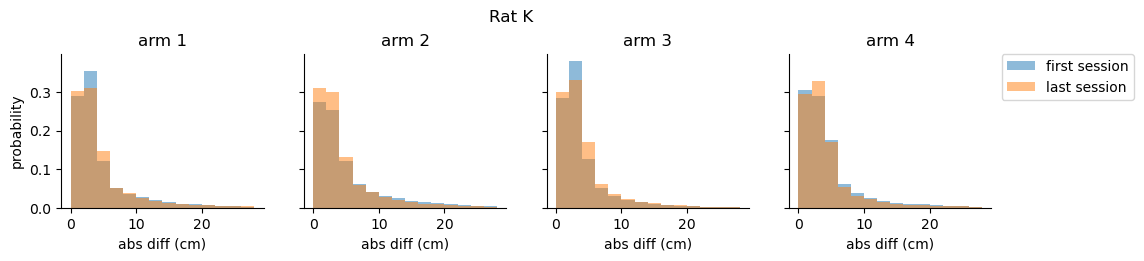

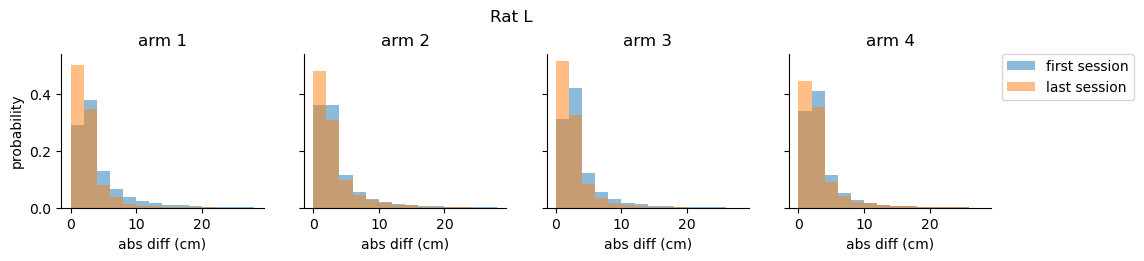

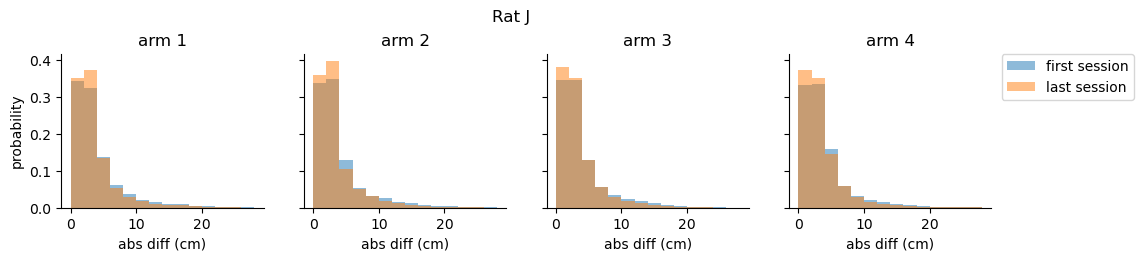

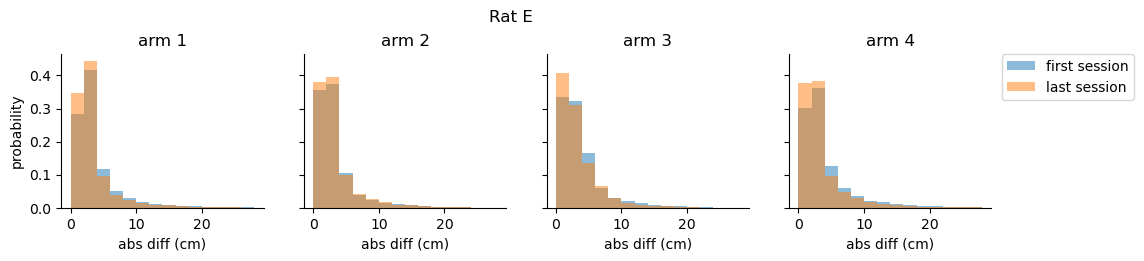

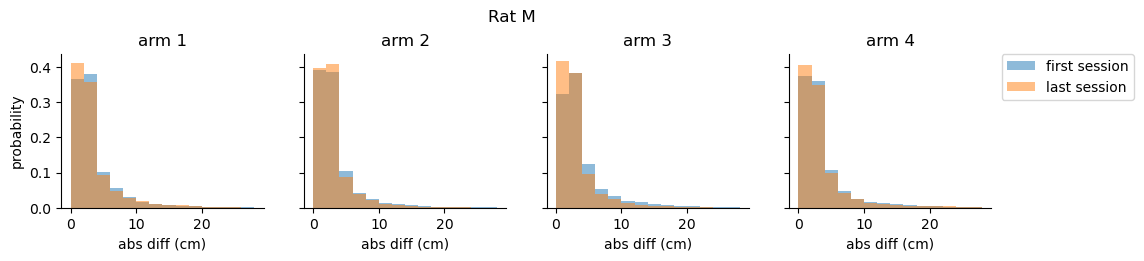

In [35]:
figure_outputfolder = '/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/supp_decode/'

animal_name_old = ""
for file_ind in range(len(nwb_copy_file_name_all)):
    
    nwb_copy_file_name = nwb_copy_file_name_all[file_ind]
    session_name = sessions_all[file_ind]
    diff_file = diff_all[nwb_copy_file_name]
    animal_name = nwb_copy_file_name[:5]
    if animal_name != animal_name_old:
        fig, axes = plt.subplots(1, 4, figsize=(12, 2),sharey = True)
        color = "C0"
        animal_name_old = animal_name
    else:
        color = "C1"
        
    
    for arm in [1,2,3,4]:
        for classifier_param_name in diff_file.keys():
            if color == "C0":
                label = f"first session" 
            elif color == "C1":
                label = f"last session" 
            diff = diff_file[classifier_param_name][arm]
            axes[arm-1].hist(diff,
                             bins = np.arange(0,30,2),
                             weights = np.ones_like(diff)/len(diff),
                             color = color, alpha = 0.5, label = label)

    if color == "C1":
        axes[0].set_title("arm 1")
        axes[1].set_title("arm 2")
        axes[2].set_title("arm 3")
        axes[3].set_title("arm 4")
        
        axes[0].set_ylabel("probability")
        axes[0].spines[['right', 'top']].set_visible(False)
        axes[1].spines[['right', 'top']].set_visible(False)
        axes[2].spines[['right', 'top']].set_visible(False)
        axes[3].spines[['right', 'top']].set_visible(False)
    
        for a in axes:
            a.set_xlabel("abs diff (cm)")
        a.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.suptitle(f"Rat {animal_name[0].upper()}",x=0.5, y=1.1)
    
        plt.savefig(os.path.join(figure_outputfolder,
                                 f'decode_accuracy_{nwb_copy_file_name}_{session_name}.pdf'),dpi=300,bbox_inches='tight')

### Error by animal 

In [55]:
diff_by_animal = {}
for animal in ["molly","eliot","klein","julio","lewis"]:
    
    diff_animal_ = []
    for file_ind in range(len(nwb_copy_file_name_all)):
        
        nwb_copy_file_name = nwb_copy_file_name_all[file_ind]
        session_name = sessions_all[file_ind]
        diff_file = diff_all[nwb_copy_file_name]
        if nwb_copy_file_name[:5] != animal:
            continue
    
        for arm in [1,2,3,4]:
            for classifier_param_name in diff_file.keys():

                diff = diff_file[classifier_param_name][arm]
                diff_animal_.append(diff)
    
    diff_animal_ = np.concatenate(diff_animal_)
    diff_by_animal[animal] = diff_animal_

#### Make violin plots

In [57]:
import seaborn as sns
from spyglass.shijiegu.changeOfMind import color_by_rat

[15:17:28][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
15-Jan-26 15:17:28 Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:17:28][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
15-Jan-26 15:17:28 Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:17:28][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
15-Jan-26 15:17:28 Deprecation: this class has been 

(-1.0, 50.0)

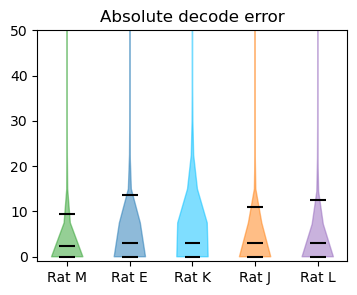

In [120]:
fig, axes = plt.subplots(1,1, figsize=(4, 3))

animals = ["molly","eliot","klein","julio","lewis"]
animal_ind = 0
for animal in animals:

    xs = np.array([0]) + (animal_ind)
    N = len(diff_by_animal[animal])

    df = pd.DataFrame()
    df['Decode Error'] = np.repeat(xs, N)
    df['values'] = np.abs(diff_by_animal[animal])
    # sns.violinplot(data=df, x='Decode Error', y='values', ax = axes, color = color_by_rat[animal],
    #            native_scale=True, orient='vertical', inner=None, linewidth=0, width=1, alpha = 0.5,
    #                cut = 0, gridsize = 100, density_norm = "area")
    parts = axes.violinplot(np.abs(diff_by_animal[animal]), positions=[animal_ind],
                            showextrema = False,
                            quantiles = [0, 0.5, 0.95])
    for pc in parts['bodies']:
        pc.set_facecolor(color_by_rat[animal])
        pc.set_edgecolor(color_by_rat[animal])
        pc.set_alpha(0.5)

    for part in ['cquantiles']:
        parts[part].set_colors('k') # Set the color of the lines
    
    # axes.errorbar([animal_ind], [np.median(df['values'])],
    #               yerr=np.array([np.quantile(df['values'],0.025), np.quantile(df['values'],0.975)]).reshape((2,-1)), color = 'k')
    animal_ind += 1

axes.set_xticks(np.arange(animal_ind))
axes.set_xticklabels(["Rat " + a[0].upper() for a in animals])
axes.set_title("Absolute decode error")

axes.set_ylim([-1,50])

### Posterior Density Playground

We assessed decoding quality based on the concentration of the posterior probability, and only
included times that were decoded with high confidence in subsequent analyses, by requiring the
highest 50% of the posterior probability values to be concentrated within 50 cm of the track

### Decode object

In [22]:
pdf_x = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
pdf_y = np.array([0, 0.05, 0.3, 0.6, 0.9, 0.1, 0.2, 0.3, 0.9, 1, 1.1])
pdf_y = pdf_y / np.sum(pdf_y)
pdf_vals = pdf_y
x_vals = pdf_x

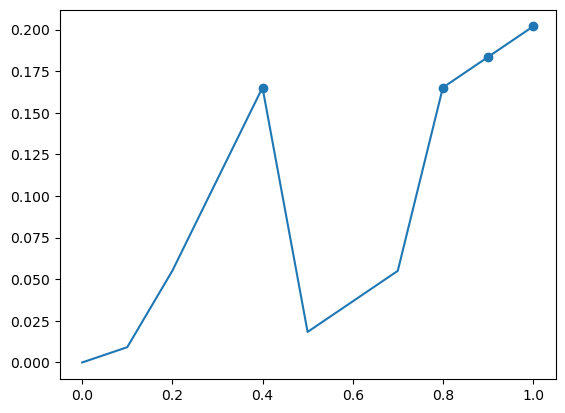

In [30]:
plt.plot(x_vals, pdf_vals)
plt.scatter(x_vals[hpd_indices], pdf_vals[hpd_indices])

array([1. , 0.9, 0.8, 0.4, 0.3, 0.2, 0.7, 0.6])

Manual 95% HPD Interval: (0.4, 1.0)


In [6]:
import arviz as az

15-Jan-26 17:30:41 arviz_base not installed
15-Jan-26 17:30:41 arviz_stats not installed
15-Jan-26 17:30:41 arviz_plots not installed


In [7]:
from spyglass.shijiegu.Analysis_SGU import DecodeResultsLinear

In [ ]:
nwb_copy_file_name_all = ['klein20231104_.nwb','klein20231107_.nwb',
                          'lewis20240105_.nwb','lewis20240109_.nwb',
                          'julio20230803_.nwb','julio20230808_.nwb',
                          'eliot20221021_.nwb','eliot20221026_.nwb',
                          'molly20220418_.nwb','molly20220416_.nwb'] #'lewis20240109_.nwb'
sessions_all = ['04_Rev2Session2','04_Rev2Session2',
                '06_Rev2Session3','04_Rev2Session2',
                '08_Seq2Session4','08_Seq2Session4',
                '04_Seq2Session2','10_Seq2Session5',
                '04_Seq2Session2','04_Seq2Session2',
               ]

In [ ]:
classifier_param_names = ["default_decoding_gpu_4armMaze"]
encoding_sets = ["2Dheadspeed_above_4"]

In [33]:
# load decode
decode_path = (DecodeResultsLinear & {"nwb_file_name":'klein20231104_.nwb',
                           "interval_list_name":'04_Rev2Session2',
                           "classifier_param_name":"default_decoding_gpu_4armMaze",
                           "encoding_set": "2Dheadspeed_above_4"}).fetch1("posterior")
decode = xr.open_dataset(decode_path)
posterior = decode.causal_posterior.sum(dim='state')

In [34]:
subset_posterior = posterior[100000:120000]

In [38]:
np.array(subset_posterior).shape

(20000, 301)

array([  0.99377522,   2.98132565,   4.96887608,   6.95642651,
         8.94397694,  10.93152737,  12.91907781,  14.90662824,
        16.89417867,  18.8817291 ,  20.86927953,  22.85682996,
        24.8443804 ,  26.83193083,  28.81948126,  30.80703169,
        32.79458212,  34.78213255,  36.76968298,  38.75723342,
        40.74478385,  42.73233428,  44.71988471,  46.70743514,
        48.69498557,  50.68253601,  52.67008644,  54.65763687,
        56.6451873 ,  58.63258948,  60.61984342,  62.60709735,
        64.59435129,  66.58160522,  68.56885916,  70.55611309,
        72.54336703,  74.53062096,  76.5178749 ,  78.50512883,
        80.49238276,  82.4796367 ,  84.46689063,  86.45414457,
        88.4413985 ,  90.42865244, 111.42227941, 132.37333876,
       134.27545746, 136.17757616, 138.07969486, 139.98181356,
       141.88393226, 143.78605097, 145.68816967, 147.59028837,
       149.49240707, 151.39452577, 153.29664448, 155.19876318,
       157.10088188, 159.00300058, 160.90511928, 162.80

In [51]:
subset_posterior_subset

<xarray.DataArray 'causal_posterior' (time: 17587, position: 301)> Size: 21MB
array([[2.1099460e-05, 4.3033742e-05, 5.8293743e-05, ..., 5.5795692e-02,
        5.5835757e-02, 4.2950436e-02],
       [2.6196166e-04, 2.7583225e-04, 2.7945233e-04, ..., 5.8195047e-02,
        5.5978674e-02, 4.3414742e-02],
       [3.2290519e-04, 3.3489315e-04, 3.3433587e-04, ..., 6.2533066e-02,
        5.8990672e-02, 4.5311283e-02],
       ...,
       [5.3664728e-04, 5.3615891e-04, 5.2516960e-04, ..., 7.5432123e-04,
        7.0879428e-04, 6.4115529e-04],
       [9.7992038e-04, 1.0884439e-03, 1.2389211e-03, ..., 5.9056445e-04,
        6.3429540e-04, 6.3939043e-04],
       [9.4208051e-04, 9.4524078e-04, 8.9944497e-04, ..., 1.0685894e-03,
        1.0671556e-03, 1.0176294e-03]], dtype=float32)
Coordinates:
  * time      (time) float64 141kB 1.699e+09 1.699e+09 ... 1.699e+09 1.699e+09
  * position  (position) float64 2kB 0.9938 2.981 4.969 ... 738.1 740.1 742.0

In [49]:
len(eligible_indices)

17587

In [ ]:
len

(array([1.3431e+04, 3.2780e+03, 5.9700e+02, 2.0500e+02, 7.6000e+01,
        2.4000e+01, 8.0000e+00, 1.3000e+01, 7.0000e+00]),
 array([ 0., 10., 20., 30., 40., 50., 60., 70., 80., 90.]),
 <BarContainer object of 9 artists>)

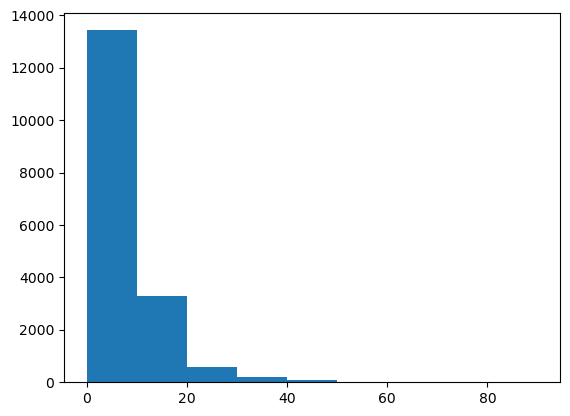

In [47]:
#plt.hist(hpd_all, bins = np.arange(0,100,10))

In [15]:
subset_posterior_dataset = az.convert_to_dataset(subset_posterior)

In [17]:
subset_posterior_dataset

<xarray.Dataset> Size: 24MB
Dimensions:           (time: 20000, position: 301)
Coordinates:
  * time              (time) float64 160kB 1.699e+09 1.699e+09 ... 1.699e+09
  * position          (position) float64 2kB 0.9938 2.981 4.969 ... 740.1 742.0
Data variables:
    causal_posterior  (time, position) float32 24MB 0.02096 0.02595 ... 0.001209

In [16]:
hpd_interval = az.hdi(subset_posterior_dataset, hdi_prob=0.95)

ValueError: Missing core dims {'chain', 'draw'} from arg number 1 on a variable named `causal_posterior`:
<xarray.Variable (time: 20000, position: 301)> Size: 24MB
array([[0.02096308, 0.02595493, 0.02466247, ..., 0.04807196, 0.05074918,
        0.04122268],
       [0.02168422, 0.02693381, 0.02571126, ..., 0.04873303, 0.05129062,
        0.04156113],
       [0.02884301, 0.03530192, 0.0323277 , ..., 0.04807485, 0.05464846,
        0.04622221],
       ...,
       [0.00126376, 0.00130183, 0.00126539, ..., 0.00143225, 0.00143894,
        0.00135666],
       [0.00098244, 0.00103015, 0.00102291, ..., 0.00140752, 0.00130315,
        0.00116243],
       [0.00099698, 0.00103469, 0.00104098, ..., 0.00162462, 0.00142034,
        0.00120895]], dtype=float32)

Either add the core dimension, or if passing a dataset alternatively pass `on_missing_core_dim` as `copy` or `drop`. 